FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/pocketgnn_architecture_diagram.png'

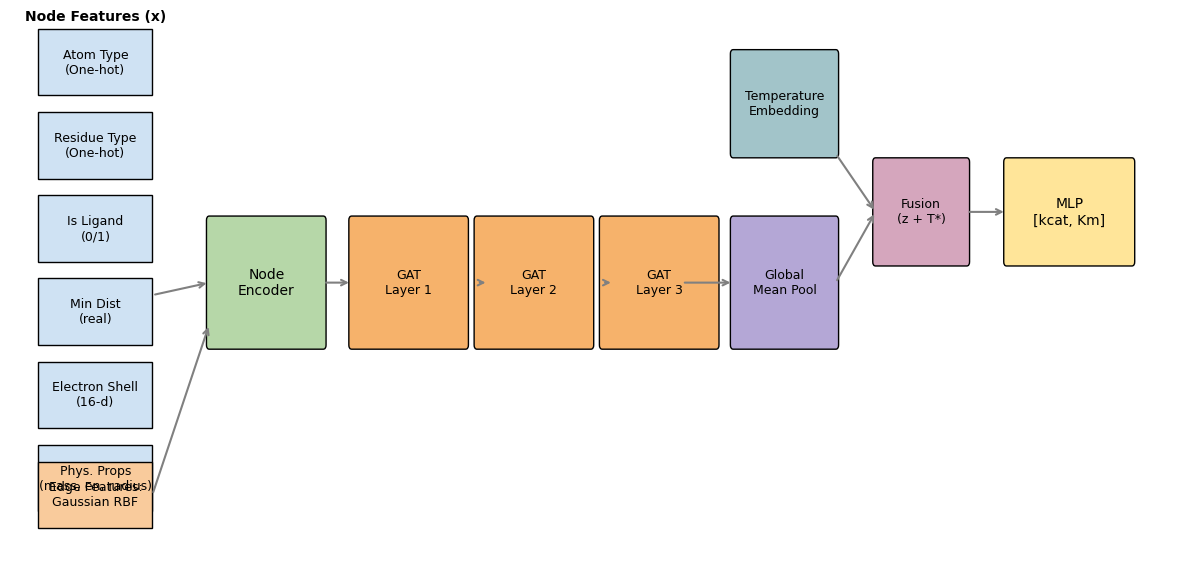

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_pocketgnn_diagram():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Node Feature Blocks
    node_feats = [
        "Atom Type\n(One-hot)",
        "Residue Type\n(One-hot)",
        "Is Ligand\n(0/1)",
        "Min Dist\n(real)",
        "Electron Shell\n(16-d)",
        "Phys. Props\n(mass, en, radius)"
    ]
    for i, label in enumerate(node_feats):
        ax.add_patch(patches.Rectangle((0.5, 5 - i), 2, 0.8, edgecolor='black', facecolor='#cfe2f3'))
        ax.text(1.5, 5 - i + 0.4, label, ha='center', va='center', fontsize=9)

    ax.text(1.5, 5.9, "Node Features (x)", ha='center', fontsize=10, weight='bold')

    # Edge Feature
    ax.add_patch(patches.Rectangle((0.5, -0.2), 2, 0.8, edgecolor='black', facecolor='#f9cb9c'))
    ax.text(1.5, 0.2, "Edge Features:\nGaussian RBF", ha='center', va='center', fontsize=9)

    # Node Encoder
    ax.add_patch(patches.FancyBboxPatch((3.5, 2), 2, 1.5, boxstyle="round,pad=0.05", edgecolor='black', facecolor='#b6d7a8'))
    ax.text(4.5, 2.75, "Node\nEncoder", ha='center', va='center', fontsize=10)

    # GAT Layers
    for i in range(3):
        ax.add_patch(patches.FancyBboxPatch((6 + i*2.2, 2), 2, 1.5, boxstyle="round,pad=0.05", edgecolor='black', facecolor='#f6b26b'))
        ax.text(7 + i*2.2, 2.75, f"GAT\nLayer {i+1}", ha='center', va='center', fontsize=9)

    # Global Pool
    ax.add_patch(patches.FancyBboxPatch((12.7, 2), 1.8, 1.5, boxstyle="round,pad=0.05", edgecolor='black', facecolor='#b4a7d6'))
    ax.text(13.6, 2.75, "Global\nMean Pool", ha='center', va='center', fontsize=9)

    # Temperature MLP
    ax.add_patch(patches.FancyBboxPatch((12.7, 4.3), 1.8, 1.2, boxstyle="round,pad=0.05", edgecolor='black', facecolor='#a2c4c9'))
    ax.text(13.6, 4.9, "Temperature\nEmbedding", ha='center', va='center', fontsize=9)

    # Add block (fused features)
    ax.add_patch(patches.FancyBboxPatch((15.2, 3), 1.6, 1.2, boxstyle="round,pad=0.05", edgecolor='black', facecolor='#d5a6bd'))
    ax.text(16.0, 3.6, "Fusion\n(z + T*)", ha='center', va='center', fontsize=9)

    # MLP Head
    ax.add_patch(patches.FancyBboxPatch((17.5, 3), 2.2, 1.2, boxstyle="round,pad=0.05", edgecolor='black', facecolor='#ffe599'))
    ax.text(18.6, 3.6, "MLP\n[kcat, Km]", ha='center', va='center', fontsize=10)

    # Arrows (manually defined)
    def arrow(xy_start, xy_end):
        ax.annotate("", xy=xy_end, xytext=xy_start,
                    arrowprops=dict(arrowstyle="->", lw=1.5, color='gray'))

    arrow((2.5, 2.6), (3.5, 2.75))  # node x → encoder
    arrow((2.5, 0.2), (3.5, 2.25))  # edge attr → encoder
    arrow((5.5, 2.75), (6, 2.75))
    arrow((8.2, 2.75), (8.4, 2.75))
    arrow((10.4, 2.75), (10.6, 2.75))
    arrow((11.8, 2.75), (12.7, 2.75))  # → global pool
    arrow((14.5, 2.75), (15.2, 3.6))   # pool → fusion
    arrow((14.5, 4.3), (15.2, 3.6))    # temp → fusion
    arrow((16.8, 3.6), (17.5, 3.6))    # fusion → MLP

    ax.set_xlim(0, 20.5)
    ax.set_ylim(-0.8, 6)
    ax.axis('off')
    plt.tight_layout()
    return fig

fig = draw_pocketgnn_diagram()
fig.savefig("/mnt/data/pocketgnn_architecture_diagram.png", dpi=300)
plt.close(fig)
